Scripts to create maps with LA County, City, and Neighborhoods.

In [1]:
# load packages 
%matplotlib inline
import os
import glob
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import geopandas as gpd
import pyproj
import shapely.geometry
from shapely.geometry import Point
from matplotlib.colors import LogNorm
from matplotlib.ticker import FormatStrFormatter, ScalarFormatter
import matplotlib as mpl
import numpy as np
import xarray as xr
import rioxarray as rxr
from geocube.api.core import make_geocube
import xesmf as xe
import cartopy.crs as ccrs
import contextily as ctx
from scipy import stats

# imports for rasterizing 
import geopandas as gpd
import rasterio
from rasterio import features
from rasterio.enums import MergeAlg
from rasterio.plot import show
import xwrf
# dask
import dask
from dask.distributed import Client, LocalCluster

In [10]:
# load data and set paths
home_path = Path('/home1/kojoseph/anthropogenic-heat-la-20230205')
data_path = home_path / 'data'
output_path = data_path / 'output'
plot_path = Path('/home1/kojoseph/ah-la-paper/figs')
# load urban area mask (based on WRF-out)
urban_area = gpd.read_file("/home1/kojoseph/ah-la-paper/data/urban_mask/wrf_urban_mask-v4.gpkg")
# load LA County boundary
la_county_filepath='/home1/kojoseph/anthropogenic-heat-la-20230205/data/boundaries/la_county_bound_simplified_3.geojson'
la_county_gdf = gpd.read_file(la_county_filepath)
# load LA City boundary
city_boundaries = gpd.read_file(data_path/'boundaries/City_Boundaries_SCAG_Region.zip')
la_boundary = city_boundaries[city_boundaries.CITY == 'Los Angeles']
la_boundary = la_boundary[['geometry']]
# load highway buffer geometry
highway_buffer = gpd.read_file(data_path / 'boundaries/highway_buffer_1km.gpkg')
highway_buffer = highway_buffer.to_crs('EPSG:4326')
# load neighborhoods 
neighborhoods_dir = data_path / 'boundaries/la_bound_nbhd.geojson'
neighborhoods = gpd.read_file(neighborhoods_dir)
# pre-define labels for easy re-use
# \mathrm{} prevents exprsesion from getting italicized 
# \/ within the latex expression is necessary for an empty space
degree_sign = u'\N{DEGREE SIGN}'
del_ta_label = r'$\mathrm{{\Delta}T_{2m}}$ (' + degree_sign + 'C)'
del_tc_label = r'$\mathrm{{\Delta}T_{c}}$ (' + degree_sign + 'C)'
del_ahf_label = r'$\Delta \mathrm{AHF}$ (W m$^{-2}$)'
ahf_label = r'AHF ($\mathrm{W\/m^{-2}}$)'
del_ws_label = r'$\mathrm{{\Delta}}$WS ($\mathrm{m\/s^{-1}}$)'
del_pblh_label = r'$\mathrm{{\Delta}}$PBLH (m)'
# color shortcutes
max_red = '#DD1717'  # red
yale_blue = '#0F4392'  # blue
# where to save plots
plot_dir ='/home1/kojoseph/ah-la-paper/figs/draft_v2'
os.makedirs(plot_dir, exist_ok=True)

# Remove Catalina Island (including Avalon) from dataframe
catalina_index = neighborhoods.query('name.str.contains("Catalina") | name.str.contains("Avalon")').index
neighborhoods.drop(catalina_index, inplace=True)
# make neighborhoods name all lower-case to match energy atlas name column
neighborhoods['name'] = neighborhoods['name'].str.lower()

In [3]:
la_county_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [9]:
extent

array([ 320478.92855923, 3685129.35490285,  440582.73814579,
       3854410.74623358])

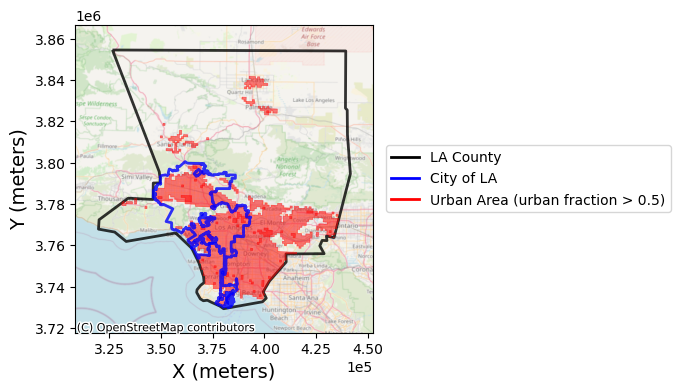

In [40]:
from matplotlib.lines import Line2D
# create map of 
map_crs = 'epsg:32611'
la_county_reproj = la_county_gdf.to_crs(map_crs)
la_city_reproj = la_boundary.to_crs(map_crs)
urban_area_reproj = urban_area.to_crs(map_crs)
fig, ax = plt.subplots(figsize=(4,4))
# Expand by 10% margin
extent = neighborhoods.to_crs(map_crs).total_bounds
xpad = 0.1 * (extent[2] - extent[0])
ypad = 0.1 * (extent[3] - extent[1])
ax.set_xlim(extent[0] - xpad, extent[2] + xpad)
ax.set_ylim(extent[1] - ypad, extent[3] + ypad)
ctx.add_basemap(ax=ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=map_crs, zoom=9, alpha=0.7)
# Overlay LA County boundary on top
la_county_reproj.boundary.plot(
    ax=ax,
    color='black',
    linewidth=2.0,
    alpha=0.8,
    zorder=10  # ensures it's drawn above the basemap
)
# Overlay LA City boundary on top
la_city_reproj.boundary.plot(
    ax=ax,
    color='blue',
    linewidth=2.0,
    alpha=0.8,
    zorder=12  # ensures it's drawn above the basemap
)
# Overlay urban area on top
urban_area_reproj.boundary.plot(
    ax=ax,
    facecolor='red',
    edgecolor='red',
    linewidth=0.5,
    alpha=0.5,
    zorder=11  # ensures it's drawn above the basemap
)
# plt.axis('off')
ax.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
legend_handles = [
    Line2D([0], [0], color='black', linewidth=2, label='LA County'),
    Line2D([0], [0], color='blue', linewidth=2, label='City of LA'),
    Line2D([0], [0], color='red', linewidth=2, label='Urban Area (urban fraction > 0.5)'),
]
ax.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True)
ax.set_xlabel("X (meters)", fontsize=14)
ax.set_ylabel("Y (meters)", fontsize=14)
filename = 'la_county_city_urban_map.png'
save_path = os.path.join(plot_dir, filename)
plt.savefig(save_path, dpi=1200, bbox_inches='tight')

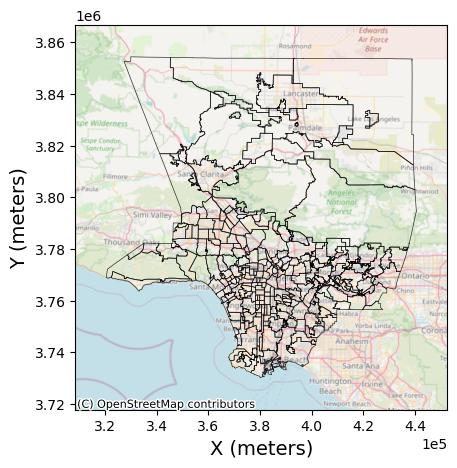

In [41]:
from matplotlib.lines import Line2D
# create map of 
map_crs = 'epsg:32611'
neighborhoods_reproj = neighborhoods.to_crs(map_crs)
fig, ax = plt.subplots(figsize=(5,5))
# Expand by 10% margin
extent = neighborhoods.to_crs(map_crs).total_bounds
xpad = 0.1 * (extent[2] - extent[0])
ypad = 0.1 * (extent[3] - extent[1])
ax.set_xlim(extent[0] - xpad, extent[2] + xpad)
ax.set_ylim(extent[1] - ypad, extent[3] + ypad)
ctx.add_basemap(ax=ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=map_crs, zoom=9, alpha=0.7)
# Overlay neighborhoods
neighborhoods_reproj.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.5,
    alpha=0.8,
    zorder=10  # ensures it's drawn above the basemap
)
# plt.axis('off')
ax.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
ax.set_xlabel("X (meters)", fontsize=14)
ax.set_ylabel("Y (meters)", fontsize=14)
filename = 'la_neighborhoods_map.png'
save_path = os.path.join(plot_dir, filename)
plt.savefig(save_path, dpi=1200, bbox_inches='tight')